In [14]:
import os
import pandas as pd
import scanpy as sc
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# 1.) SCEPTRE empirical p-values
#sceptre_empirical_p = pd.read_csv('data/discovery_pairs_empirical_pvalues.tsv.gz', sep = '\t') # Janas Path
#sceptre_empirical_p = pd.read_csv("/g/steinmetz/project/otar_2063/promoter_screen/interpretation/diff_expr_analyses/process_trans_analysis/gene_level_empirical_pvalues/all_pairs_empirical_pvalues_per_gene.tsv.gz", sep = '\t')
#sceptre_empirical_p = sceptre_empirical_p.rename(columns = {'grna_target': 'KO', 'gene_symbol': 'gene_name', 'log_2_fold_change': 'LFC_SCEPTRE_empirical', 'pval_adj_per_gene': 'pval_SCEPTRE'})

In [16]:
# 2.) SCEPTRE (normal p-values)
#sceptre = pd.read_csv('data/all_discovery_pairs.tsv.gz', sep = '\t') # Janas Path
sceptre = pd.read_csv('/g/steinmetz/project/otar_2063/promoter_screen/interpretation/diff_expr_analyses/process_trans_analysis/sceptre_pvalues/all_pairs.tsv.gz', sep = '\t') # Janas Path
sceptre = sceptre.rename(columns = {'grna_target': 'KO', 'gene_symbol': 'gene_name', 'log_2_fold_change': 'LFC_SCEPTRE', 'p_value_adj': 'pval_SCEPTRE'})

In [17]:
# 3.) Limma
limma = pd.read_csv('/g/steinmetz/project/otar_2063/promoter_screen/interpretation/DE/output/combined/DEG_single_cell_limma_ebayes_split_NT_removed_all_covariates_prefiltered_genes_gene_combined_2026-02-03.tsv.gz')
limma = limma.rename(columns = {'Perturbation': 'KO', 'Target': 'gene_name', 'logFC': 'LFC_limma', 'adj.P.Val': 'pval_limma'})

In [27]:
# 4.) Pseudo-bulk
def load_deg_results(file_path, pval_threshold = None):
    df_list = []
    for file_name in os.listdir(file_path):
        df_tmp = pd.read_csv(os.path.join(file_path, file_name))
        if pval_threshold is not None:
            df_tmp = df_tmp[df_tmp["pvals_adj"] < pval_threshold]
        df_list.append(df_tmp)
    df1 = pd.concat(df_list)
    return df1

#bulk = load_deg_results('/g/stegle/schrod/code/TCell/results_pseudobulk/DEG_bulk_rerun')
bulk = load_deg_results('/g/stegle/schrod/code/TCell/results_pseudobulk/Wilcoxon_bulk_final_cutoff_2')
bulk = bulk.rename(columns = {'group': 'KO', 'names': 'gene_name', 'scores': 'LFC_bulk', 'pvals_adj': 'pval_bulk'})

In [19]:
# 5.) DESeq2
DESeq = load_deg_results('/g/stegle/schrod/code/TCell/pseudobulk_deseq2_chunks50_min3bulks_ribosomal')
DESeq = DESeq.rename(columns = {'contrast': 'KO', 'variable': 'gene_name', 'log_fc': 'LFC_DESeq', 'adj_p_value': 'pval_DESeq'})

In [20]:
# Wilcoxon single_cell
wilcoxon = load_deg_results('/g/stegle/schrod/code/TCell/results_single_cell/Wilcoxon_single_cell_final')
wilcoxon = wilcoxon.rename(columns = {'group': 'KO', 'names': 'gene_name', 'scores': 'LFC_wilcoxon', 'pvals_adj': 'pval_wilcoxon'})

In [28]:
# Overview of results for each method
def analyze_dataset(df, method_name, pval_col, ko_col='KO', gene_col='gene_name'):
    """Analyze a dataset: total hits, significant hits, and on-target hits"""
    # Filter to significant hits
    df_sig = df[df[pval_col] < 0.1].copy()
    
    # Count on-target hits (where gene_name == KO)
    on_target_sig = (df_sig[gene_col] == df_sig[ko_col]).sum()
    on_target_all = (df[gene_col] == df[ko_col]).sum()
    
    # Number of unique KOs tested
    n_kos = df[ko_col].nunique()
    
    return {
        'Method': method_name,
        'N KOs tested': n_kos,
        'Sig hits (p<0.1)': len(df_sig),
        'On-target sig hits': on_target_sig,
        'On-target sig %': f"{100 * on_target_sig / n_kos:.2f}%" if len(df_sig) > 0 else "N/A",
        'Fraction on target for all hits': f"{100 * on_target_sig / len(df_sig):.2f}%" if on_target_all > 0 else "N/A"
    }

results_overview = []

# Analyze each dataset
results_overview.append(analyze_dataset(sceptre, 'SCEPTRE', 'pval_SCEPTRE'))
#results_overview.append(analyze_dataset(sceptre_empirical_p, 'SCEPTRE_empirical', 'pval_SCEPTRE'))
results_overview.append(analyze_dataset(wilcoxon, 'Wilcoxon', 'pval_wilcoxon'))
results_overview.append(analyze_dataset(limma, 'Limma', 'pval_limma'))
results_overview.append(analyze_dataset(bulk, 'Pseudobulk', 'pval_bulk'))
results_overview.append(analyze_dataset(DESeq, 'DESeq2', 'pval_DESeq'))

# Create summary DataFrame
overview_df = pd.DataFrame(results_overview)
print("\n=== Method Comparison Overview ===")
print(overview_df.to_string(index=False))
print("\n")


=== Method Comparison Overview ===
    Method  N KOs tested  Sig hits (p<0.1)  On-target sig hits On-target sig % Fraction on target for all hits
   SCEPTRE          7638            393967                5436          71.17%                           1.38%
  Wilcoxon          7623           1216182                4709          61.77%                           0.39%
     Limma          7636            516895                5221          68.37%                           1.01%
Pseudobulk          7300              7977                 639           8.75%                           8.01%
    DESeq2          7300             96762                4311          59.05%                           4.46%




In [29]:
sceptre_nt = pd.read_csv("/g/steinmetz/project/otar_2063/promoter_screen/interpretation/diff_expr_analyses/process_trans_analysis/sceptre_pvalues_filt_genes/results_run_calibration_check_filtered.tsv.gz", sep = '\t')

In [30]:
print("Sceptre fraction of NT hits:", sceptre_nt["significant_fdr10"].sum()/sceptre_nt.shape[0])

Sceptre fraction of NT hits: 0.00483


In [35]:
### Add calibration results!!


fraction_nt_discoveries = {
    "SCEPTRE": 0.00483,
    "Wilcoxon": 0.0181,   #Number of significant hits (pval<0.1): 117172 total number of tests: 6475368 Fraction of significant hits: 0.0181
    "Limma": 0.00648,
    "Pseudobulk": 0.00000428,
    "DESeq2": 0.0002,
    }

In [36]:
# Add calibration results to overview_df
overview_df['NT_discovery_fraction'] = overview_df['Method'].map(fraction_nt_discoveries)
# Convert to percentage
overview_df['NT_discovery_pct'] = overview_df['NT_discovery_fraction'] * 100
overview_df

,Method,N KOs tested,Sig hits (p<0.1),On-target sig hits,On-target sig %,Fraction on target for all hits,NT_discovery_fraction,NT_discovery_pct,On-target_pct,Fraction_on_target_pct
0,SCEPTRE,7638,393967,5436,71.17%,1.38%,0.004830,0.483000,71.17,1.38
1,Wilcoxon,7623,1216182,4709,61.77%,0.39%,0.018100,1.810000,61.77,0.39
2,Limma,7636,516895,5221,68.37%,1.01%,0.006480,0.648000,68.37,1.01
3,Pseudobulk,7300,7977,639,8.75%,8.01%,0.000004,0.000428,8.75,8.01
4,DESeq2,7300,96762,4311,59.05%,4.46%,0.000200,0.020000,59.05,4.46


Saved DEG method comparison plot to /g/stegle/schrod/code/TCell/plots/final/DEG_method_comparison.pdf


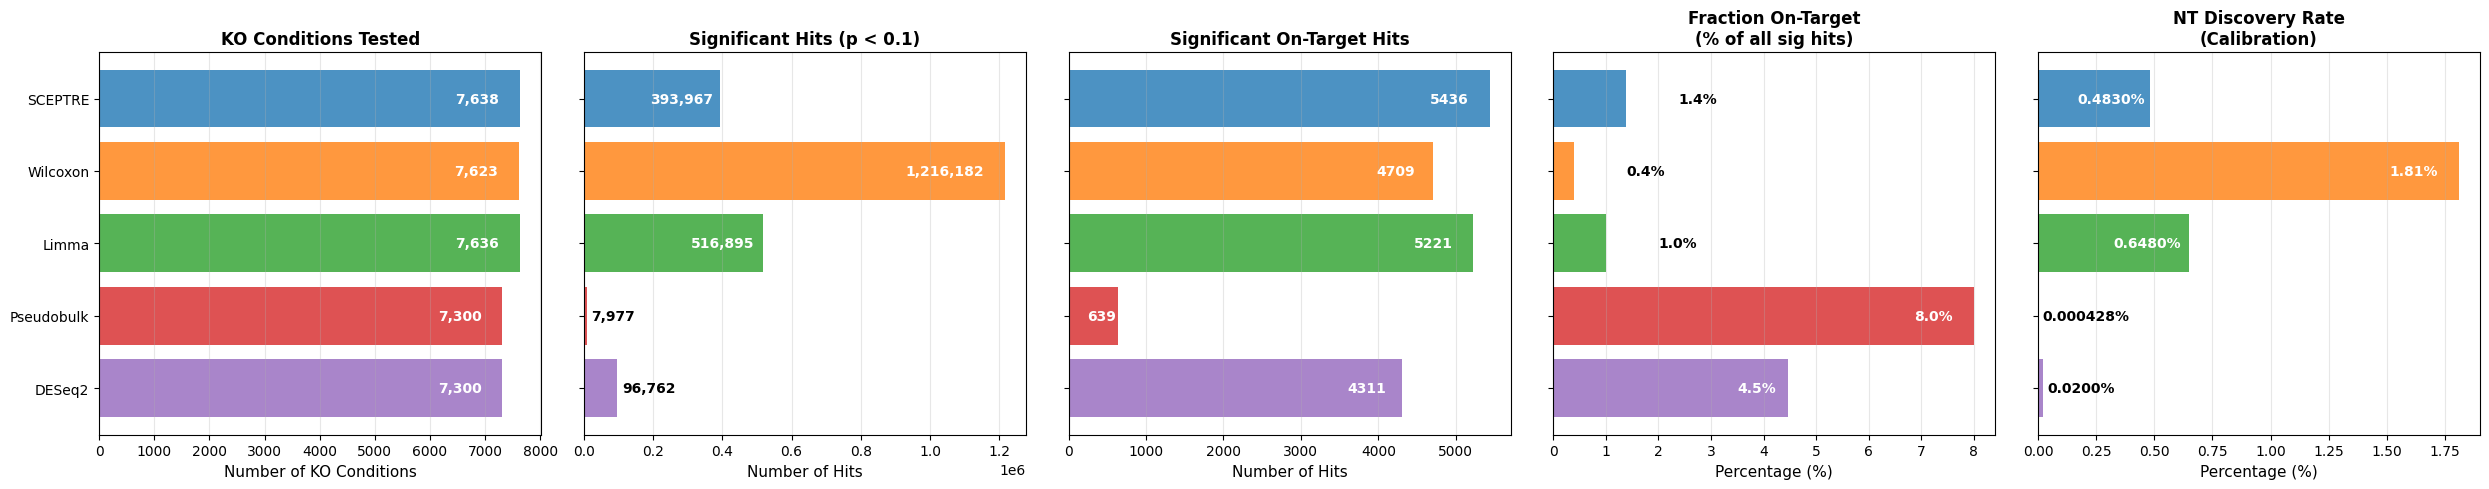

In [37]:
# Create overview visualization
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

# Extract numeric values from percentage strings
overview_df['On-target_pct'] = overview_df['On-target sig %'].str.rstrip('%').astype(float)
overview_df['Fraction_on_target_pct'] = overview_df['Fraction on target for all hits'].str.rstrip('%').astype(float)

# Define colors for each method
method_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Plot 1: Number of KO conditions tested
ax1 = axes[0]
bars1 = ax1.barh(range(len(overview_df)), overview_df['N KOs tested'], 
                 color=method_colors[:len(overview_df)], alpha=0.8)
ax1.set_yticks(range(len(overview_df)))
ax1.set_yticklabels(overview_df['Method'])
ax1.set_xlabel('Number of KO Conditions', fontsize=11)
ax1.set_title('KO Conditions Tested', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.invert_yaxis()  # Highest on top
# Add value labels
for i, bar in enumerate(bars1):
    width = bar.get_width()
    max_width = ax1.get_xlim()[1]
    # If bar is less than 10% of max width, put label outside
    if width < max_width * 0.1:
        ax1.text(width + max_width * 0.01, bar.get_y() + bar.get_height()/2.,
                 f'{int(width):,}', ha='left', va='center', fontsize=10, color='black', fontweight='bold')
    else:
        ax1.text(width * 0.95, bar.get_y() + bar.get_height()/2.,
                 f'{int(width):,}', ha='right', va='center', fontsize=10, color='white', fontweight='bold')

# Plot 2: Number of significant hits
ax2 = axes[1]
bars2 = ax2.barh(range(len(overview_df)), overview_df['Sig hits (p<0.1)'], 
                 color=method_colors[:len(overview_df)], alpha=0.8)
ax2.set_yticks(range(len(overview_df)))
ax2.set_yticklabels([])
ax2.set_xlabel('Number of Hits', fontsize=11)
ax2.set_title('Significant Hits (p < 0.1)', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.invert_yaxis()  # Highest on top
# Add value labels
for i, bar in enumerate(bars2):
    width = bar.get_width()
    max_width = ax2.get_xlim()[1]
    # If bar is less than 10% of max width, put label outside
    if width < max_width * 0.1:
        ax2.text(width + max_width * 0.01, bar.get_y() + bar.get_height()/2.,
                 f'{int(width):,}', ha='left', va='center', fontsize=10, color='black', fontweight='bold')
    else:
        ax2.text(width * 0.95, bar.get_y() + bar.get_height()/2.,
                 f'{int(width):,}', ha='right', va='center', fontsize=10, color='white', fontweight='bold')

# Plot 3: On-target significant hits
ax3 = axes[2]
bars3 = ax3.barh(range(len(overview_df)), overview_df['On-target sig hits'], 
                 color=method_colors[:len(overview_df)], alpha=0.8)
ax3.set_yticks(range(len(overview_df)))
ax3.set_yticklabels([])
ax3.set_xlabel('Number of Hits', fontsize=11)
ax3.set_title('Significant On-Target Hits', fontsize=12, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)
ax3.invert_yaxis()  # Highest on top
# Add value labels
for i, bar in enumerate(bars3):
    width = bar.get_width()
    max_width = ax3.get_xlim()[1]
    # If bar is less than 10% of max width, put label outside
    if width < max_width * 0.1:
        ax3.text(width + max_width * 0.01, bar.get_y() + bar.get_height()/2.,
                 f'{int(width)}', ha='left', va='center', fontsize=10, color='black', fontweight='bold')
    else:
        ax3.text(width * 0.95, bar.get_y() + bar.get_height()/2.,
                 f'{int(width)}', ha='right', va='center', fontsize=10, color='white', fontweight='bold')

# Plot 4: Fraction of on-target hits among all significant hits
ax4 = axes[3]
bars4 = ax4.barh(range(len(overview_df)), overview_df['Fraction_on_target_pct'], 
                 color=method_colors[:len(overview_df)], alpha=0.8)
ax4.set_yticks(range(len(overview_df)))
ax4.set_yticklabels([])
ax4.set_xlabel('Percentage (%)', fontsize=11)
ax4.set_title('Fraction On-Target\n(% of all sig hits)', fontsize=12, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)
ax4.invert_yaxis()  # Highest on top
# Add value labels
for i, bar in enumerate(bars4):
    width = bar.get_width()
    method = overview_df.iloc[i]['Method']
    
    # Force Pseudobulk and DESeq2 labels inside the bar
    if method in ['Pseudobulk', 'DESeq2']:
        ax4.text(width * 0.95, bar.get_y() + bar.get_height()/2.,
                 f'{width:.1f}%', ha='right', va='center', fontsize=10, color='white', fontweight='bold')
    # If bar is less than 10% of max width (100), put label outside
    elif width < 10:
        ax4.text(width + 1, bar.get_y() + bar.get_height()/2.,
                 f'{width:.1f}%', ha='left', va='center', fontsize=10, color='black', fontweight='bold')
    else:
        ax4.text(width * 0.95, bar.get_y() + bar.get_height()/2.,
                 f'{width:.1f}%', ha='right', va='center', fontsize=10, color='white', fontweight='bold')

# Plot 5: Fraction of NT discoveries (false positive rate)
ax5 = axes[4]
bars5 = ax5.barh(range(len(overview_df)), overview_df['NT_discovery_pct'], 
                 color=method_colors[:len(overview_df)], alpha=0.8)
ax5.set_yticks(range(len(overview_df)))
ax5.set_yticklabels([])
ax5.set_xlabel('Percentage (%)', fontsize=11)
ax5.set_title('NT Discovery Rate\n(Calibration)', fontsize=12, fontweight='bold')
ax5.grid(axis='x', alpha=0.3)
ax5.invert_yaxis()  # Highest on top
# Add value labels
for i, bar in enumerate(bars5):
    width = bar.get_width()
    # Format based on scale
    if width >= 1:
        label_text = f'{width:.2f}%'
    elif width >= 0.01:
        label_text = f'{width:.4f}%'
    else:
        label_text = f'{width:.6f}%'
    
    # Position label outside for small bars
    max_width = ax5.get_xlim()[1]
    if width < max_width * 0.15:
        ax5.text(width + max_width * 0.01, bar.get_y() + bar.get_height()/2.,
                 label_text, ha='left', va='center', fontsize=10, color='black', fontweight='bold')
    else:
        ax5.text(width * 0.95, bar.get_y() + bar.get_height()/2.,
                 label_text, ha='right', va='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
save_path = '/g/stegle/schrod/code/TCell/plots/final/DEG_method_comparison.pdf'
plt.savefig(save_path)
print(f"Saved DEG method comparison plot to {save_path}")
plt.show()
